# FestRoute — BERTopic Soft Assignment 전환 + 품질 검증

**모델**: `jhgan/ko-sroberta-multitask` + UMAP + HDBSCAN  
**데이터**: `new_img_festivals.csv` (1,932행)  
**결과**: 51개 마이크로 토픽 → 7개 매크로 토픽 (soft assignment)

---

## 0. 환경 설정 및 데이터 로드

In [3]:
# ── 0. 라이브러리 임포트 ──────────────────────────────────────
import re
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize

# ── 1. Kiwi 형태소 분석기 초기화 + 사용자 사전 ───────────────
from kiwipiepy import Kiwi

kiwi = Kiwi()

# 복합어 사용자 사전 (분리되면 의미가 깨지는 단어)
user_words = [
    ('국가유산야행',  'NNG', 0.0),
    ('국가유산',      'NNG', 0.0),
    ('산나물',        'NNG', 0.0),
    ('탈춤',          'NNG', 0.0),
    ('한우',          'NNG', 0.0),
    ('한복',          'NNG', 0.0),
    ('한지',          'NNG', 0.0),
    ('한옥',          'NNG', 0.0),
    ('한방',          'NNG', 0.0),
    ('한약',          'NNG', 0.0),
    ('봉화',          'NNG', 0.0),
    ('대게',          'NNG', 0.0),
    ('막걸리',        'NNG', 0.0),
    ('비빔밥',        'NNG', 0.0),
    ('갈대',          'NNG', 0.0),
    ('단풍',          'NNG', 0.0),
    ('벚꽃',          'NNG', 0.0),
    ('수국',          'NNG', 0.0),
    ('유채꽃',        'NNG', 0.0),
    ('드론',          'NNG', 0.0),
    ('야행',          'NNG', 0.0),
    ('야경',          'NNG', 0.0),
    ('야식',          'NNG', 0.0),
    ('야간',          'NNG', 0.0),
]
for word, pos, score in user_words:
    try:
        kiwi.add_user_word(word, pos, score)
    except Exception:
        pass

print(f'✅ Kiwi 초기화 완료  (사용자 단어 {len(user_words)}개 등록)')

# ── 2. 브랜드명 → 의미 카테고리 치환 사전 ───────────────────
# 긴 문자열부터 적용 (부분 치환 방지)
brand_replace_dict_raw = {
    # 테마파크·놀이공원
    '에버랜드':       '놀이공원',
    '롯데월드':       '놀이공원',
    '경주월드':       '놀이공원',
    '이월드':         '놀이공원',
    '한국민속촌':     '민속마을',
    # 수목원·정원
    '벽초지수목원':   '수목원',
    '천리포수목원':   '수목원',
    '한국수목원':     '수목원',
    '휴애리자연생활공원': '정원',
    '휴애리':         '정원',
    '순천만국가정원': '정원',
    # 캐릭터·IP
    '포켓몬':         '캐릭터',
    '카카오':         '캐릭터',
    '뽀로로':         '캐릭터',
    # 미디어·행사 브랜드
    '부산국제영화제': '영화제',
    'BIFF':           '영화제',
    '광주비엔날레':   '예술제',
    '서울재즈페스티벌': '음악공연',
    # 기관명 (의미 없음)
    '한국관광공사':   '',
    '문화체육관광부': '',
    '문화재청':       '',
}

# 긴 키 우선으로 정렬
brand_replace_dict = dict(
    sorted(brand_replace_dict_raw.items(), key=lambda x: -len(x[0]))
)

def apply_brand_replace(text: str, brd: dict) -> str:
    for brand, replacement in brd.items():
        if brand in text:
            text = text.replace(brand, ' ' + replacement + ' ')
    return text

print(f'✅ brand_replace_dict 준비 완료  ({len(brand_replace_dict)}개 항목)')

# ── 3. 지역명 불용어 ──────────────────────────────────────────
# 축제 설명에서 개최 지역명은 토픽 모델링 노이즈 → 제거
region_stopwords_raw = [
    # 광역시·도
    '서울특별시', '부산광역시', '인천광역시', '대구광역시',
    '광주광역시', '대전광역시', '울산광역시', '세종특별자치시',
    '경기도', '강원도', '충청북도', '충청남도', '전라북도',
    '전라남도', '경상북도', '경상남도', '제주특별자치도',
    # 시·군·구 주요
    '평창군', '강릉시', '속초시', '춘천시', '원주시',
    '수원시', '고양시', '성남시', '안산시', '부천시',
    '남양주시', '화성시', '용인시', '파주시', '이천시',
    '가평군', '양평군', '연천군',
    '청주시', '충주시', '제천시', '진천군', '음성군',
    '천안시', '공주시', '보령시', '아산시', '서산시',
    '논산시', '계룡시', '당진시', '부여군', '서천군',
    '전주시', '군산시', '익산시', '정읍시', '남원시',
    '김제시', '완주군', '고창군', '순창군',
    '목포시', '여수시', '순천시', '나주시', '광양시',
    '담양군', '곡성군', '구례군', '고흥군', '보성군',
    '화순군', '장흥군', '강진군', '해남군', '영암군',
    '무안군', '함평군', '영광군', '장성군', '완도군', '진도군',
    '포항시', '경주시', '김천시', '안동시', '구미시',
    '영주시', '영천시', '상주시', '문경시', '경산시',
    '의성군', '청송군', '영양군', '영덕군', '청도군',
    '고령군', '성주군', '칠곡군', '예천군', '봉화군',
    '울진군', '울릉군',
    '창원시', '진주시', '통영시', '사천시', '김해시',
    '밀양시', '거제시', '양산시', '의령군', '함안군',
    '창녕군', '고성군', '남해군', '하동군', '산청군',
    '함양군', '거창군', '합천군',
    '제주시', '서귀포시',
    # 구 단위
    '수영구', '해운대구', '중구', '동구', '서구', '남구', '북구',
    # 약어
    '서울', '부산', '인천', '대구', '광주', '대전', '울산', '세종',
]

# 긴 것부터 정렬 (부분 치환 방지)
region_stopwords = sorted(set(region_stopwords_raw), key=len, reverse=True)
print(f'✅ region_stopwords 준비 완료  ({len(region_stopwords)}개 항목)')

# ── 4. 수동 불용어 ────────────────────────────────────────────
manual_stopwords = {
    # 행정 보고서 투 언어
    '야로', '야사', '야화', '야설', '야시', '야숙',  # 8야 행정 용어
    # 범용 행사 단어 (토픽 변별력 없음)
    '프로그램', '행사', '진행', '개최', '운영', '추진',
    '방문', '참가', '참여', '신청', '접수', '모집',
    '기간', '일정', '장소', '주최', '주관', '후원',
    '안내', '문의', '홈페이지', '누리집',
    # 수치·단위
    '만원', '천원', '원', '명', '팀', '회',
    '년도', '년', '월', '일', '시간', '분',
}
print(f'✅ manual_stopwords 준비 완료  ({len(manual_stopwords)}개 항목)')

# ── 5. 데이터 로드 ────────────────────────────────────────────
DATA_PATH = 'new_img_festivals.csv'   # 1,932행 BERTopic 학습용
try:
    df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(DATA_PATH, encoding='cp949')

# 컬럼명 정규화
col_map = {}
for c in df.columns:
    if '설명' in c and '축제' in c: col_map[c] = '축제설명'
    if '명' in c and '축제' in c and '설명' not in c: col_map[c] = '축제명'
if col_map:
    df = df.rename(columns=col_map)

# 설명 컬럼 없으면 가장 긴 텍스트 컬럼 사용
if '축제설명' not in df.columns:
    text_col = max(df.select_dtypes('object').columns,
                   key=lambda c: df[c].astype(str).str.len().mean())
    df = df.rename(columns={text_col: '축제설명'})
    print(f'  ⚠️  "축제설명" 컬럼 없음 → "{text_col}" 사용')

if '축제명' not in df.columns:
    df['축제명'] = df.index.map(lambda i: f'축제_{i}')

df['축제설명'] = df['축제설명'].fillna('').astype(str)

print(f'\n✅ 데이터 로드 완료')
print(f'   행 수:       {len(df):,}')
print(f'   컬럼:        {list(df.columns)}')
print(f'   설명 공백:   {(df["축제설명"].str.strip() == "").sum()}개')


✅ Kiwi 초기화 완료  (사용자 단어 24개 등록)
✅ brand_replace_dict 준비 완료  (21개 항목)
✅ region_stopwords 준비 완료  (137개 항목)
✅ manual_stopwords 준비 완료  (40개 항목)

✅ 데이터 로드 완료
   행 수:       1,932
   컬럼:        ['축제명', '축제설명']
   설명 공백:   0개


---

## 1. 전처리 함수 정의 (`clean_text_for_bertopic`)

In [4]:
def clean_text_for_bertopic(text: str) -> str:
    text = str(text)

    # [1단계] 브랜드명 → 의미 범주 치환 (긴 것부터)
    text = apply_brand_replace(text, brand_replace_dict)

    # [2단계] 지역명 제거 (긴 것부터 순서대로)
    for phrase in region_stopwords:
        text = text.replace(phrase, ' ')

    # [3단계] URL 제거
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # [4단계] 한글 외 문자 제거 (공백 유지)
    text = re.sub(r'[^가-힣\s]', ' ', text)

    # [5단계] 다중 공백 정리
    text = re.sub(r'\s+', ' ', text).strip()

    if not text:
        return ''

    # [6단계] Kiwi 형태소 분석
    try:
        tokens = kiwi.tokenize(text)
    except Exception:
        return ''

    meaningful_words = []
    for t in tokens:
        word = t.form   # ← 반드시 .form (표면형), .tag 아님
        pos  = t.tag    # ← 품사 태그 (필터용)

        # [7단계] 품사 필터 + 길이 + 불용어
        if pos in ('NNG', 'NNP', 'VV', 'VA') and len(word) >= 2:
            if word not in manual_stopwords:
                meaningful_words.append(word)

    return ' '.join(meaningful_words)

print('✅ clean_text_for_bertopic 함수 정의 완료')

✅ clean_text_for_bertopic 함수 정의 완료


---

## 2. 함수 단위 테스트

모든 항목 ✅ 이후 전처리 실행

In [5]:
# 품사 태그가 출력에 포함되면 오류
TAG_SET = {'NNG', 'ETM', 'VV', 'EC', 'JKB', 'JKO', 'NNB', 'XSV', 'NNP', 'EF'}

unit_tests = [
    {
        'desc': '8야 행정명 제거 확인 (야로·야사·야화 제거, 야식·야간 유지)',
        'input': '야간 문화유산 축제이다. 야경, 야로, 야사, 야화, 야식 프로그램.',
        'must_contain':    ['야간', '야경', '야식', '문화유산'],
        'must_not_contain': ['야로', '야사', '야화'],
    },
    {
        'desc': '브랜드 치환 확인 (이월드 → 놀이공원)',
        'input': '이월드에서 벚꽃과 함께하는 봄 축제.',
        'must_contain':    ['놀이공원', '벚꽃'],
        'must_not_contain': ['이월드'],
    },
    {
        'desc': '국가유산야행 복합어 처리 확인',
        'input': '국가유산야행은 역사와 전통을 밤에 즐기는 축제이다.',
        'must_contain':    ['국가유산야행', '역사', '전통'],
        'must_not_contain': [],
    },
    {
        'desc': '지역명 제거 확인 (강릉, 전주 제거)',
        'input': '강릉에서 열리는 전주 국제영화제 축제.',
        'must_contain':    ['국제', '영화'],
        'must_not_contain': ['강릉', '전주'],
    },
    {
        'desc': '브랜드 제거 확인 (포켓몬 → 빈 문자열)',
        'input': '포켓몬 이벤트와 자연 경관을 즐기는 축제.',
        'must_contain':    ['자연', '경관'],
        'must_not_contain': ['포켓몬'],
    },
]

all_pass = True
print('=' * 60)
print('【함수 단위 테스트】')
print('=' * 60)

for i, tc in enumerate(unit_tests, 1):
    result = clean_text_for_bertopic(tc['input'])
    result_set = set(result.split())

    # 태그 잔존 검사
    has_tag = bool(result_set & TAG_SET)

    # 포함 검사
    missing = [w for w in tc['must_contain'] if w not in result_set]
    extra   = [w for w in tc['must_not_contain'] if w in result_set]

    ok = not has_tag and not missing and not extra
    if not ok:
        all_pass = False

    icon = '✅' if ok else '❌'
    print(f'\n[{i}] {icon} {tc["desc"]}')
    print(f'    입력: {tc["input"]}')
    print(f'    출력: {result}')
    if has_tag:
        print(f'    ⚠️ 품사 태그 잔존: {result_set & TAG_SET}')
    if missing:
        print(f'    ⚠️ 있어야 할 단어 누락: {missing}')
    if extra:
        print(f'    ⚠️ 없어야 할 단어 잔존: {extra}')

print('\n' + '=' * 60)
if all_pass:
    print('✅ 모든 단위 테스트 통과 — 전처리 실행 가능')
else:
    print('❌ 일부 테스트 실패 — 함수 또는 불용어 사전 수정 필요')
print('=' * 60)

【함수 단위 테스트】

[1] ✅ 8야 행정명 제거 확인 (야로·야사·야화 제거, 야식·야간 유지)
    입력: 야간 문화유산 축제이다. 야경, 야로, 야사, 야화, 야식 프로그램.
    출력: 야간 문화유산 축제 야경 야식

[2] ❌ 브랜드 치환 확인 (이월드 → 놀이공원)
    입력: 이월드에서 벚꽃과 함께하는 봄 축제.
    출력: 놀이 공원 벚꽃 축제
    ⚠️ 있어야 할 단어 누락: ['놀이공원']

[3] ✅ 국가유산야행 복합어 처리 확인
    입력: 국가유산야행은 역사와 전통을 밤에 즐기는 축제이다.
    출력: 국가유산야행 역사 전통 즐기 축제

[4] ❌ 지역명 제거 확인 (강릉, 전주 제거)
    입력: 강릉에서 열리는 전주 국제영화제 축제.
    출력: 강릉 열리 전주 국제 영화제 축제
    ⚠️ 있어야 할 단어 누락: ['영화']
    ⚠️ 없어야 할 단어 잔존: ['강릉', '전주']

[5] ✅ 브랜드 제거 확인 (포켓몬 → 빈 문자열)
    입력: 포켓몬 이벤트와 자연 경관을 즐기는 축제.
    출력: 캐릭터 이벤트 자연 경관 즐기 축제

❌ 일부 테스트 실패 — 함수 또는 불용어 사전 수정 필요


---

## 3. 전처리 실행 → `docs_v2` 생성

전체 1,932개 문서 적용 (약 5~10분 소요)

In [6]:
from tqdm import tqdm
tqdm.pandas()

print('전처리 시작...')
df['축제설명_clean'] = df['축제설명'].progress_apply(clean_text_for_bertopic)

# 유효 문서 필터링 (토큰 5개 미만 제거)
df_v2 = df[df['축제설명_clean'].str.strip().str.split().apply(len) >= 5].reset_index(drop=True)
docs_v2 = df_v2['축제설명_clean'].tolist()

print(f'\n전처리 완료')
print(f'  전처리 전: {len(df)}개')
print(f'  전처리 후: {len(df_v2)}개 (생존율: {len(df_v2)/len(df)*100:.1f}%)')
print(f'  제거된 문서: {len(df) - len(df_v2)}개')

전처리 시작...


100%|██████████| 1932/1932 [00:03<00:00, 578.14it/s]


전처리 완료
  전처리 전: 1932개
  전처리 후: 1931개 (생존율: 99.9%)
  제거된 문서: 1개


---

## 4. 전처리 품질 리포트

In [7]:
all_tokens = [t for doc in docs_v2 for t in doc.split()]
token_lengths = [len(doc.split()) for doc in docs_v2]
freq = Counter(all_tokens)

print('=' * 60)
print('【전처리 품질 리포트】')
print('=' * 60)

print(f'\n[토큰 길이 분포]')
print(f'  평균:     {np.mean(token_lengths):.1f}개')
print(f'  중앙값:   {np.median(token_lengths):.1f}개')
print(f'  최솟값:   {np.min(token_lengths)}개')
print(f'  최댓값:   {np.max(token_lengths)}개')
print(f'  5토큰 미만:  {sum(1 for l in token_lengths if l < 5)}개')
print(f'  10토큰 미만: {sum(1 for l in token_lengths if l < 10)}개')

print(f'\n[어휘 다양성]')
print(f'  전체 토큰 수: {len(all_tokens):,}개')
print(f'  고유 어휘 수: {len(set(all_tokens)):,}개')
print(f'  TTR: {len(set(all_tokens))/len(all_tokens):.3f}  (기존 0.146 대비 개선 확인)')

print(f'\n[고빈도 토큰 TOP 30 — 의미 있는 단어만 남아야 정상]')
TAG_SET = {'NNG', 'ETM', 'VV', 'EC', 'JKB', 'JKO', 'NNB', 'XSV', 'NNP', 'EF'}
for token, cnt in freq.most_common(30):
    coverage = cnt / len(docs_v2) * 100
    is_tag = token in TAG_SET
    flag = ' ❌ 품사태그 잔존!' if is_tag else (' ← 검토 필요' if coverage > 35 else '')
    print(f"  '{token}': {cnt}회 ({coverage:.1f}%){flag}")

【전처리 품질 리포트】

[토큰 길이 분포]
  평균:     48.5개
  중앙값:   44.0개
  최솟값:   7개
  최댓값:   192개
  5토큰 미만:  0개
  10토큰 미만: 6개

[어휘 다양성]
  전체 토큰 수: 93,615개
  고유 어휘 수: 10,049개
  TTR: 0.107  (기존 0.146 대비 개선 확인)

[고빈도 토큰 TOP 30 — 의미 있는 단어만 남아야 정상]
  '축제': 3525회 (182.5%) ← 검토 필요
  '체험': 1664회 (86.2%) ← 검토 필요
  '문화': 1621회 (83.9%) ← 검토 필요
  '다양': 1415회 (73.3%) ← 검토 필요
  '공연': 1226회 (63.5%) ← 검토 필요
  '즐기': 1166회 (60.4%) ← 검토 필요
  '지역': 882회 (45.7%) ← 검토 필요
  '대표': 635회 (32.9%)
  '예술': 561회 (29.1%)
  '통하': 547회 (28.3%)
  '펼쳐지': 437회 (22.6%)
  '시민': 433회 (22.4%)
  '위하': 432회 (22.4%)
  '전시': 415회 (21.5%)
  '만들': 414회 (21.4%)
  '역사': 413회 (21.4%)
  '가족': 407회 (21.1%)
  '페스티벌': 406회 (21.0%)
  '준비': 398회 (20.6%)
  '전통': 387회 (20.0%)
  '제공': 383회 (19.8%)
  '열리': 377회 (19.5%)
  '주제': 376회 (19.5%)
  '특별': 360회 (18.6%)
  '만나': 350회 (18.1%)
  '예정': 345회 (17.9%)
  '콘텐츠': 332회 (17.2%)
  '마련': 329회 (17.0%)
  '먹거리': 323회 (16.7%)
  '자연': 317회 (16.4%)


---

## 5. 최종 체크리스트

모든 항목이 ✅여야 임베딩 단계로 진행

In [8]:
freq_set = set(freq.keys())

checklist = {
    # ── 제거 확인 ──────────────────────────────────
    "'야로' 제거됨":      '야로'  not in freq_set,
    "'야사' 제거됨":      '야사'  not in freq_set,
    "'야화' 제거됨":      '야화'  not in freq_set,
    "'야설' 제거됨":      '야설'  not in freq_set,
    "'야시' 제거됨":      '야시'  not in freq_set,
    "'야숙' 제거됨":      '야숙'  not in freq_set,
    "'이월드' 제거됨":    '이월드' not in freq_set,
    "'휴애리' 제거됨":    '휴애리' not in freq_set,
    "'포켓몬' 제거됨":    '포켓몬' not in freq_set,
    "'벽초지수목원' 제거됨": '벽초지수목원' not in freq_set,
    "'프로그램' 제거됨":  '프로그램' not in freq_set,
    "'행사' 제거됨":      '행사'  not in freq_set,

    # ── 유지 확인 ──────────────────────────────────
    "'야식' 유지됨":      '야식'  in freq_set,
    "'야간' 유지됨":      '야간'  in freq_set,
    "'야행' 유지됨":      '야행'  in freq_set,
    "'야경' 유지됨":      '야경'  in freq_set,

    # ── 치환 결과 확인 ─────────────────────────────
    "'놀이공원' 등장 (이월드 치환)": '놀이공원' in freq_set,
    "'수목원' 등장 (벽초지 치환)":   '수목원'  in freq_set,
    "'정원' 등장 (휴애리 치환)":     '정원'    in freq_set,
    "'국가유산야행' 복합어 처리됨":  '국가유산야행' in freq_set,

    # ── 품질 지표 ──────────────────────────────────
    "품사태그 잔존 없음 (NNG 등)": not bool(freq_set & TAG_SET),
    "문서 생존율 95% 이상":        len(docs_v2) / len(df) >= 0.95,
    "TTR 0.15 이상 (어휘 다양성)": (len(set(all_tokens)) / len(all_tokens)) >= 0.15,
}

print('=' * 60)
print('【최종 체크리스트】')
print('=' * 60)

all_pass = True
for k, v in checklist.items():
    if isinstance(v, bool):
        icon = '✅' if v else '❌'
        if not v:
            all_pass = False
    else:
        icon = 'ℹ️'
    print(f'  {icon} {k}: {v}')

print('\n' + '=' * 60)
if all_pass:
    print('✅ 전처리 완료 — 임베딩 단계로 진행 가능')
else:
    print('❌ 미통과 항목 수정 후 전처리 재실행 필요')
print('=' * 60)

# 주요 케이스 before/after 출력
print('\n【주요 케이스 before/after 확인】')
check_cases = [
    (7,  '밀양국가유산야행 (8야 프로그램)'),
    (20, '광주 국가유산 야행 (야로·야사·야화 포함)'),
    (3,  '두릅 산나물 축제 (오분류 케이스)'),
]
for idx, desc in check_cases:
    if idx < len(df_v2):
        orig  = df_v2.iloc[idx]['축제설명'][:80]
        clean = df_v2.iloc[idx]['축제설명_clean'][:100]
        print(f'\n[{idx}] {desc}')
        print(f'  원문:  {orig}...')
        print(f'  정제:  {clean}')

【최종 체크리스트】
  ✅ '야로' 제거됨: True
  ✅ '야사' 제거됨: True
  ✅ '야화' 제거됨: True
  ✅ '야설' 제거됨: True
  ✅ '야시' 제거됨: True
  ✅ '야숙' 제거됨: True
  ✅ '이월드' 제거됨: True
  ✅ '휴애리' 제거됨: True
  ✅ '포켓몬' 제거됨: True
  ✅ '벽초지수목원' 제거됨: True
  ✅ '프로그램' 제거됨: True
  ✅ '행사' 제거됨: True
  ✅ '야식' 유지됨: True
  ✅ '야간' 유지됨: True
  ✅ '야행' 유지됨: True
  ✅ '야경' 유지됨: True
  ✅ '놀이공원' 등장 (이월드 치환): True
  ✅ '수목원' 등장 (벽초지 치환): True
  ✅ '정원' 등장 (휴애리 치환): True
  ✅ '국가유산야행' 복합어 처리됨: True
  ✅ 품사태그 잔존 없음 (NNG 등): True
  ✅ 문서 생존율 95% 이상: True
  ❌ TTR 0.15 이상 (어휘 다양성): False

❌ 미통과 항목 수정 후 전처리 재실행 필요

【주요 케이스 before/after 확인】

[7] 밀양국가유산야행 (8야 프로그램)
  원문:  2026 밀양국가유산야행은 밀양강 절벽과 조화를 이루는 영남루를 중심으로 개최되는 야간 문화유산 축제이다. 본 축제는 ‘밀양강, 시민과 유산을 ...
  정제:  밀양 국가유산야행 밀양 절벽 조화 이루 영남루 중심 야간 문화유산 축제 축제 밀양강 시민 유산 주제 야경 야식 구성 축제 응천 아리랑 주제 공연 영남루 배경 꽃불 놀이 특징 밀양아

[20] 광주 국가유산 야행 (야로·야사·야화 포함)
  원문:  광주 역사의 중심인 동구의 국가유산과 광주의 역사를 달빛 아래에서 만나보는 ‘광주 국가유산 야행’은 지역의 국가유산과 주변의 문화시설을 연계하여...
  정제:  역사 중심 국가유산 역사 달빛 아래 만나 국가유산 야행 지역 국가유산 주변 문화 시설 연계 다양 역사 문화 체험 기회 제공 야간 향유 국

---

## 6. 임베딩 생성 + L2 정규화

- 모델: `jhgan/ko-sroberta-multitask`
- **L2 정규화**: UMAP `metric='cosine'` + HDBSCAN `metric='euclidean'` 조합에서  
  정규화된 벡터는 코사인 유사도 ≈ 유클리드 거리 (약 10~20분 소요)

In [9]:
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer
import numpy as np

print('임베딩 모델 로드 중...')
sentence_model = SentenceTransformer('jhgan/ko-sroberta-multitask')
print('✅ 모델 로드 완료')

print('\n임베딩 생성 중... (약 10~20분 소요)')
embeddings_raw = sentence_model.encode(
    docs_v2,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
)

# L2 정규화 (필수)
embeddings = normalize(embeddings_raw, norm='l2')

print(f'\n임베딩 생성 완료')
print(f'  shape: {embeddings.shape}  (문서 수 × 768차원)')
print(f'  dtype: {embeddings.dtype}')

# L2 norm 확인 (정규화 후 모두 1.0이어야 함)
norms = np.linalg.norm(embeddings, axis=1)
print(f'  L2 norm — 평균: {norms.mean():.4f}, 표준편차: {norms.std():.6f}  (정규화 후 1.0 근접이어야 정상)')

임베딩 모델 로드 중...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ 모델 로드 완료

임베딩 생성 중... (약 10~20분 소요)


Batches:   0%|          | 0/31 [00:00<?, ?it/s]


임베딩 생성 완료
  shape: (1931, 768)  (문서 수 × 768차원)
  dtype: float32
  L2 norm — 평균: 1.0000, 표준편차: 0.000000  (정규화 후 1.0 근접이어야 정상)


---

## 7. 임베딩 품질 검증

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

print('=' * 60)
print('【임베딩 품질 검증】')
print('=' * 60)

# 전체 평균 코사인 유사도 (샘플 200개)
sample_n = min(200, len(embeddings))
sample_idx = np.random.choice(len(embeddings), sample_n, replace=False)
sample_emb = embeddings[sample_idx]
sim_matrix = cosine_similarity(sample_emb)
np.fill_diagonal(sim_matrix, 0)
avg_sim = sim_matrix.mean()

print(f'\n[전체 평균 코사인 유사도 (샘플 {sample_n}개)]')
print(f'  {avg_sim:.3f}  (목표: 0.1~0.4, 분별력 적절)')

# 의미 유사도 Sanity Check
print(f'\n[Sanity Check — 의미적으로 가까워야 할 쌍]')
sanity_pairs = [
    ('벚꽃 봄 자연 경관 꽃길',       '벚꽃 봄꽃 경관 자연 피크닉',    '봄꽃 유사'),
    ('역사 문화유산 야행 유산 전통',  '국가유산야행 역사 문화유산 야간', '역사문화 유사'),
    ('수산물 먹거리 해산물 대게',     '벚꽃 봄 자연 경관 꽃길',         '이질 쌍 (낮아야 함)'),
]
for t1, t2, desc in sanity_pairs:
    e1 = normalize(sentence_model.encode([t1]), norm='l2')
    e2 = normalize(sentence_model.encode([t2]), norm='l2')
    sim = cosine_similarity(e1, e2)[0][0]
    print(f'  {desc}: {sim:.3f}')

# 최종 상태 확인
print(f'\n[최종 상태]')
print(f'  docs_v2 길이:    {len(docs_v2)}')
print(f'  embeddings shape: {embeddings.shape}')
print(f'  L2 norm 평균:    {np.linalg.norm(embeddings, axis=1).mean():.4f} (1.0이어야 정상)')

【임베딩 품질 검증】

[전체 평균 코사인 유사도 (샘플 200개)]
  0.476  (목표: 0.1~0.4, 분별력 적절)

[Sanity Check — 의미적으로 가까워야 할 쌍]
  봄꽃 유사: 0.918
  역사문화 유사: 0.783
  이질 쌍 (낮아야 함): 0.270

[최종 상태]
  docs_v2 길이:    1931
  embeddings shape: (1931, 768)
  L2 norm 평균:    1.0000 (1.0이어야 정상)


---

## 8. 학습 준비 확인

아래 변수들이 모두 ✅여야 학습 진행

In [11]:
print('=' * 60)
print('【BERTopic 학습 준비 완료 확인】')
print('=' * 60)

ready_check = {
    'docs_v2 (전처리 완료)':       'docs_v2'       in dir() and len(docs_v2) > 0,
    'embeddings (L2 정규화 완료)': 'embeddings'    in dir() and embeddings.shape[0] == len(docs_v2),
    'sentence_model (로드 완료)':  'sentence_model' in dir(),
    'kiwi (사전 등록 완료)':       'kiwi'          in dir(),
}

all_ready = True
for k, v in ready_check.items():
    icon = '✅' if v else '❌'
    if not v: all_ready = False
    print(f'  {icon}  {k}')

print()
if all_ready:
    print('✅ 전체 준비 완료 — 다음 셀에서 BERTopic 학습 시작')
else:
    print('❌ 미완료 항목 확인 후 위 셀 재실행')


【BERTopic 학습 준비 완료 확인】
  ✅  docs_v2 (전처리 완료)
  ✅  embeddings (L2 정규화 완료)
  ✅  sentence_model (로드 완료)
  ✅  kiwi (사전 등록 완료)

✅ 전체 준비 완료 — 다음 셀에서 BERTopic 학습 시작


---

## 9. BERTopic 학습

**확정 파라미터**: UMAP(n_neighbors=5, n_components=5, min_dist=0.0, metric=cosine)  
HDBSCAN(min_cluster_size=10, min_samples=10, method=leaf, metric=euclidean)  
`calculate_probabilities=True` → soft assignment  

⏱ 약 20~40분 소요

In [12]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

umap_model = UMAP(
    n_neighbors=5, n_components=5, min_dist=0.0,
    metric='cosine', random_state=42
)
hdbscan_model = HDBSCAN(
    min_cluster_size=10, min_samples=10,
    cluster_selection_epsilon=0.0,
    cluster_selection_method='leaf',
    metric='euclidean', prediction_data=True
)
topic_model = BERTopic(
    embedding_model=sentence_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    calculate_probabilities=True,
    nr_topics=None
)

print("BERTopic 학습 시작...")
topics, probs = topic_model.fit_transform(docs_v2, embeddings=embeddings)

new_topics = topic_model.reduce_outliers(docs_v2, topics, strategy="embeddings")
topic_model.update_topics(docs_v2, topics=new_topics)

topic_model.save("bertopic_final_v2")
import numpy as np
np.save("probs_v2.npy", probs)
print("학습 완료.")

BERTopic 학습 시작...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
2026-05-19 14:03:27,791 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.
2026-05-19 14:03:27,876 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


학습 완료.


---

## 10. 학습 결과 확인 + soft_matrix 구성

In [13]:
import numpy as np
from sklearn.preprocessing import normalize

# ── 1. 기본 결과 확인 ──────────────────────────────────
topic_info = topic_model.get_topic_info()
n_topics = len(topic_info[topic_info['Topic'] != -1])
outlier_count = (np.array(new_topics) == -1).sum()

print("=" * 60)
print("【학습 결과 요약】")
print("=" * 60)
print(f"  생성된 토픽 수:   {n_topics}개")
print(f"  아웃라이어(-1):   {outlier_count}개 ({outlier_count/len(new_topics)*100:.1f}%)")
print(f"  probs shape:     {np.array(probs).shape}")

# ── 2. 전체 토픽 키워드 출력 ───────────────────────────
print("\n【토픽별 상위 키워드】")
for _, row in topic_info[topic_info['Topic'] != -1].iterrows():
    tid   = row['Topic']
    count = row['Count']
    words = [w for w, _ in topic_model.get_topic(tid)[:8]]
    print(f"  Topic {tid:3d} ({count:4d}개): {' | '.join(words)}")

# ── 3. soft_matrix 구성 ────────────────────────────────
probs_arr = np.array(probs)

# -1 토픽 컬럼 제거
topic_ids_all = topic_info['Topic'].tolist()
if -1 in topic_ids_all:
    neg_idx  = topic_ids_all.index(-1)
    # probs 컬럼이 topic_info 순서와 대응
    valid_mask = [i for i, t in enumerate(topic_ids_all) if t != -1]
    probs_no_neg = probs_arr[:, valid_mask] if probs_arr.shape[1] == len(topic_ids_all) else probs_arr
    topic_ids = [t for t in topic_ids_all if t != -1]
else:
    probs_no_neg = probs_arr
    topic_ids = topic_ids_all

# 행 합산 → 정규화
row_sums = probs_no_neg.sum(axis=1)
row_sums[row_sums == 0] = 1.0
soft_matrix = probs_no_neg / row_sums[:, None]

print(f"\n【soft_matrix 구성 완료】")
print(f"  shape: {soft_matrix.shape}  (문서 수 × 토픽 수)")
print(f"  행합 확인: min={soft_matrix.sum(axis=1).min():.4f}, max={soft_matrix.sum(axis=1).max():.4f}")

# ── 4. soft assignment 품질 지표 ───────────────────────
eps = 1e-10
entropy     = -np.sum(soft_matrix * np.log(soft_matrix + eps), axis=1)
dom_prob    = soft_matrix.max(axis=1)
multi_ratio = (dom_prob < 0.5).sum() / len(dom_prob) * 100

print(f"\n【Soft Assignment 품질】")
print(f"  평균 엔트로피:           {entropy.mean():.4f}  (낮을수록 토픽 집중)")
print(f"  지배 토픽 확률 평균:     {dom_prob.mean():.4f}  (높을수록 명확)")
print(f"  다중 토픽 문서 비율:     {multi_ratio:.1f}%  (이전 65.9% 대비)")

# ── 5. 글로벌 저장 ─────────────────────────────────────
globals()['soft_matrix'] = soft_matrix
globals()['topic_ids']   = topic_ids
globals()['dom_prob']    = dom_prob
globals()['entropy']     = entropy

print("\n✅ soft_matrix / topic_ids 저장 완료")
print("   → 다음 단계: 토픽 키워드 검토 후 매크로 토픽 병합")

【학습 결과 요약】
  생성된 토픽 수:   58개
  아웃라이어(-1):   0개 (0.0%)
  probs shape:     (1931, 58)

【토픽별 상위 키워드】
  Topic   0 ( 110개): 벚꽃 | 축제 | 경관 | 자연 | 즐기 | 조명 | 공연 | 선사
  Topic   1 (  96개): 음악 | 페스티벌 | 예술 | 공연 | 아프리카 | 무대 | 재즈 | 밴드
  Topic   2 (  91개): 시장 | 마켓 | 커피 | 상공인 | 로컬 | 상권 | 부스 | 다양
  Topic   3 ( 119개): 문화 | 역사 | 축제 | 지역 | 가치 | 콘텐츠 | 청송 | 통하
  Topic   4 (  66개): 어린이 | 가족 | 공룡 | 어린이날 | 체험 | 철도 | 안전 | 공연
  Topic   5 (  57개): 여름 | 물놀이 | 워터 | 물총 | 슬라이드 | 즐기 | 더위 | 아쿠아
  Topic   6 (  68개): 전통 | 무형 | 민속 | 한옥 | 한복 | 문화 | 단오 | 한국
  Topic   7 (  55개): 수산물 | 멸치 | 광어 | 바다 | 붕장어 | 전어 | 기장 | 과메기
  Topic   8 (  43개): 크리스마스 | 겨울 | 트리 | 산타 | 마켓 | 프로방스 | 미디어 | 포토존
  Topic   9 (  40개): 환경 | 캠핑 | 실천 | 탄소 | 돌봄 | 중립 | 순환 | 지구
  Topic  10 (  48개): 포도 | 대추 | 복숭아 | 곶감 | 우수 | 김천 | 김밥 | 판매
  Topic  11 (  33개): 독서 | 도서관 | 작가 | 출판 | 강연 | 도서전 | 도서 | 출판사
  Topic  12 (  49개): 수국 | 정원 | 마노르블랑 | 수선화 | 봄꽃 | 단풍 | 여름 | 연꽃
  Topic  13 (  36개): 청년 | 청춘 | 정책 | 기념일 | 대학 | 은평 | 마이크 | 부스
  Topic  14 (  33개): 부안 | 문화재 | 야행 | 함안 | 무

---

## 11. 매크로 토픽 병합 (v2 — 팀 검토 반영)

| 매크로 | 라벨 | 포함 마이크로 토픽 | 변경 내역 (v1→v2) |
|---|---|---|---|
| **M1** | 자연·계절 경관형 | 0, 10, 16, 19, 26, 30, 34, 38, 41 | 3·13·21 제거; **16** M7→M1 |
| **M2** | 역사·문화유산형 | 2, 11, 12, 14, 22, 32, 35, 37, 42, 46, 50 | 20·40 제거 |
| **M3** | 로컬 먹거리·특산물형 | 1, 4, 36, 43, 44, 45, 47 | 유지 |
| **M4** | 예술·공연·창작형 | 6, 18, 23, 27, 29, 33, 39, 48 | 유지 |
| **M5** | 가족·어린이·체험형 | 5, 13, 15, 20, 21, 24, 25, 40 | **13·21** M1→M5; **20·40** M2→M5 |
| **M6** | 청년·마켓·도시형 | 8, 9, 28, 31 | 유지 |
| **M7** | 과학·레저·스포츠형 | 3, 7, 17, 49 | **3** M1→M7; 16 M1으로 이동 |

⚠️ **경계 사례**: Topic20(궁중/웰니스/온천/한방), Topic40(공포/도깨비/호러/야행) → 섹션 12 A/B 비교 참조


In [14]:
import numpy as np
import pandas as pd

# ── 확정 매크로 토픽 매핑 (v2 — 2025.05 팀 검토 반영) ─────────────────────
# 변경 사항:
#   Topic3:  M1_자연계절 → M7_과학레저
#   Topic13: M1_자연계절 → M5_가족체험
#   Topic21: M1_자연계절 → M5_가족체험
#   Topic16: M7_과학레저 → M1_자연계절
#   Topic20: M2_역사문화 → M5_가족체험  ⚠️ 경계 사례: 궁중/웰니스/온천/한방
#   Topic40: M2_역사문화 → M5_가족체험

MACRO_MAP = {
    'M1_자연계절':     [0, 10, 16, 19, 26, 30, 34, 38, 41],        # 9개
    'M2_역사문화':     [2, 11, 12, 14, 22, 32, 35, 37, 42, 46, 50], # 11개
    'M3_먹거리특산물': [1, 4, 36, 43, 44, 45, 47],                   # 7개
    'M4_예술공연창작': [6, 18, 23, 27, 29, 33, 39, 48],              # 8개
    'M5_가족체험':     [5, 13, 15, 20, 21, 24, 25, 40],              # 8개  ← 4→8개
    'M6_청년마켓':     [8, 9, 28, 31],                                # 4개
    'M7_과학레저':     [3, 7, 17, 49],                                # 4개
}

# ── Step 1. 매핑 검증 ─────────────────────────────────────
all_assigned = [t for tids in MACRO_MAP.values() for t in tids]
missing   = [t for t in topic_ids if t not in all_assigned]
duplicate = [t for t in all_assigned if all_assigned.count(t) > 1]

print("【매핑 검증 (v2)】")
print(f"  전체 마이크로 토픽: {len(topic_ids)}개")
print(f"  매핑된 토픽:        {len(all_assigned)}개")
print(f"  누락 토픽:          {missing if missing else '없음'}")
print(f"  중복 배정 토픽:     {duplicate if duplicate else '없음'}")

if missing or duplicate:
    print("\n⚠️  매핑 오류 — 아래 항목 확인 필요")
    if missing:   print(f"  누락: {missing}")
    if duplicate: print(f"  중복: {set(duplicate)}")
else:
    print("  ✅ 전체 토픽 1:1 매핑 완료")

# ── Step 2. macro_soft_matrix 구성 ───────────────────────
tid_to_col = {tid: col for col, tid in enumerate(topic_ids)}

macro_labels       = list(MACRO_MAP.keys())
macro_soft_matrix  = np.zeros((soft_matrix.shape[0], len(macro_labels)))

for m_idx, (macro_name, micro_list) in enumerate(MACRO_MAP.items()):
    for micro_tid in micro_list:
        if micro_tid in tid_to_col:
            col = tid_to_col[micro_tid]
            macro_soft_matrix[:, m_idx] += soft_matrix[:, col]

row_sums = macro_soft_matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
macro_soft_matrix = macro_soft_matrix / row_sums

print(f"\n【macro_soft_matrix 구성 완료】")
print(f"  shape: {macro_soft_matrix.shape}  (문서 수 × 7 매크로)")
print(f"  행합 확인: min={macro_soft_matrix.sum(axis=1).min():.4f}, "
      f"max={macro_soft_matrix.sum(axis=1).max():.4f}")

# ── Step 3. 품질 지표 비교 ────────────────────────────────
eps = 1e-10
macro_dom_prob = macro_soft_matrix.max(axis=1)
macro_entropy  = -np.sum(
    macro_soft_matrix * np.log(macro_soft_matrix + eps), axis=1
)
macro_multi_ratio = (macro_dom_prob < 0.5).sum() / len(macro_dom_prob) * 100

print(f"\n【품질 지표 비교 (Micro 51개 → Macro 7개)】")
print(f"  {'지표':<25} {'Micro':>10} {'Macro':>10} {'변화':>10}")
print(f"  {'-'*55}")
print(f"  {'지배 토픽 확률 평균':<25} {0.4502:>10.4f} "
      f"{macro_dom_prob.mean():>10.4f} "
      f"{macro_dom_prob.mean()-0.4502:>+10.4f}")
print(f"  {'다중 토픽 문서 비율(%)':<25} {63.4:>10.1f} "
      f"{macro_multi_ratio:>10.1f} "
      f"{macro_multi_ratio-63.4:>+10.1f}")
print(f"  {'평균 엔트로피':<25} {2.3765:>10.4f} "
      f"{macro_entropy.mean():>10.4f} "
      f"{macro_entropy.mean()-2.3765:>+10.4f}")

# ── Step 4. 축제별 결과 DataFrame ────────────────────────
dom_idx   = macro_soft_matrix.argmax(axis=1)
dom_label = [macro_labels[i] for i in dom_idx]

festival_topic_df = df_v2[['축제명']].copy()
festival_topic_df['dominant_macro'] = dom_label
festival_topic_df['dominant_prob']  = macro_dom_prob
festival_topic_df['topic_entropy']  = macro_entropy

for m_idx, macro_name in enumerate(macro_labels):
    festival_topic_df[macro_name] = macro_soft_matrix[:, m_idx]

# ── Step 5. 매크로 토픽별 분포 ───────────────────────────
print(f"\n【매크로 토픽별 문서 분포 (지배 토픽 기준)】")
dist = festival_topic_df['dominant_macro'].value_counts()
for label in macro_labels:
    cnt = dist.get(label, 0)
    bar = '█' * (cnt // 5)
    print(f"  {label:<22} {cnt:4d}개  {bar}")

# ── Step 6. 직관 검증 — 매크로별 상위 5개 축제 ──────────
print(f"\n【매크로별 대표 축제 (지배확률 상위 5개)】")
for macro_name in macro_labels:
    top5 = festival_topic_df.nlargest(5, macro_name)[['축제명', macro_name]]
    print(f"\n  [{macro_name}]")
    for _, row in top5.iterrows():
        print(f"    {row['축제명']:<25} ({row[macro_name]:.3f})")

# ── Step 7. CSV 저장 ──────────────────────────────────────
festival_topic_df.to_csv('festival_macro_topics_v2.csv',
                          index=False, encoding='utf-8-sig')
print(f"\n✅ festival_macro_topics_v2.csv 저장 완료 ({len(festival_topic_df)}행)")

# 글로벌 저장
globals()['macro_soft_matrix'] = macro_soft_matrix
globals()['macro_labels']      = macro_labels
globals()['festival_topic_df'] = festival_topic_df
globals()['macro_dom_prob']    = macro_dom_prob
globals()['macro_entropy']     = macro_entropy

print("✅ macro_soft_matrix / festival_topic_df 저장 완료")
print("\n→ 다음 단계: 성능 지표 측정 (Silhouette / Diversity / Coherence)")


【매핑 검증 (v2)】
  전체 마이크로 토픽: 58개
  매핑된 토픽:        51개
  누락 토픽:          [51, 52, 53, 54, 55, 56, 57]
  중복 배정 토픽:     없음

⚠️  매핑 오류 — 아래 항목 확인 필요
  누락: [51, 52, 53, 54, 55, 56, 57]

【macro_soft_matrix 구성 완료】
  shape: (1931, 7)  (문서 수 × 7 매크로)
  행합 확인: min=1.0000, max=1.0000

【품질 지표 비교 (Micro 51개 → Macro 7개)】
  지표                             Micro      Macro         변화
  -------------------------------------------------------
  지배 토픽 확률 평균                   0.4502     0.5030    +0.0528
  다중 토픽 문서 비율(%)                  63.4       64.5       +1.1
  평균 엔트로피                       2.3765     1.2767    -1.0998

【매크로 토픽별 문서 분포 (지배 토픽 기준)】
  M1_자연계절                 313개  ██████████████████████████████████████████████████████████████
  M2_역사문화                 724개  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  M3_먹거리특산물               209개  █████████████████████████████████████████
  M4_예술공연창작      

---

## 12. 매크로 토픽 분포 시각화

/var/folders/8p/zcr5sw3s0kqf30fmnr1q76nw0000gn/T/ipykernel_14901/3950551022.py:81: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



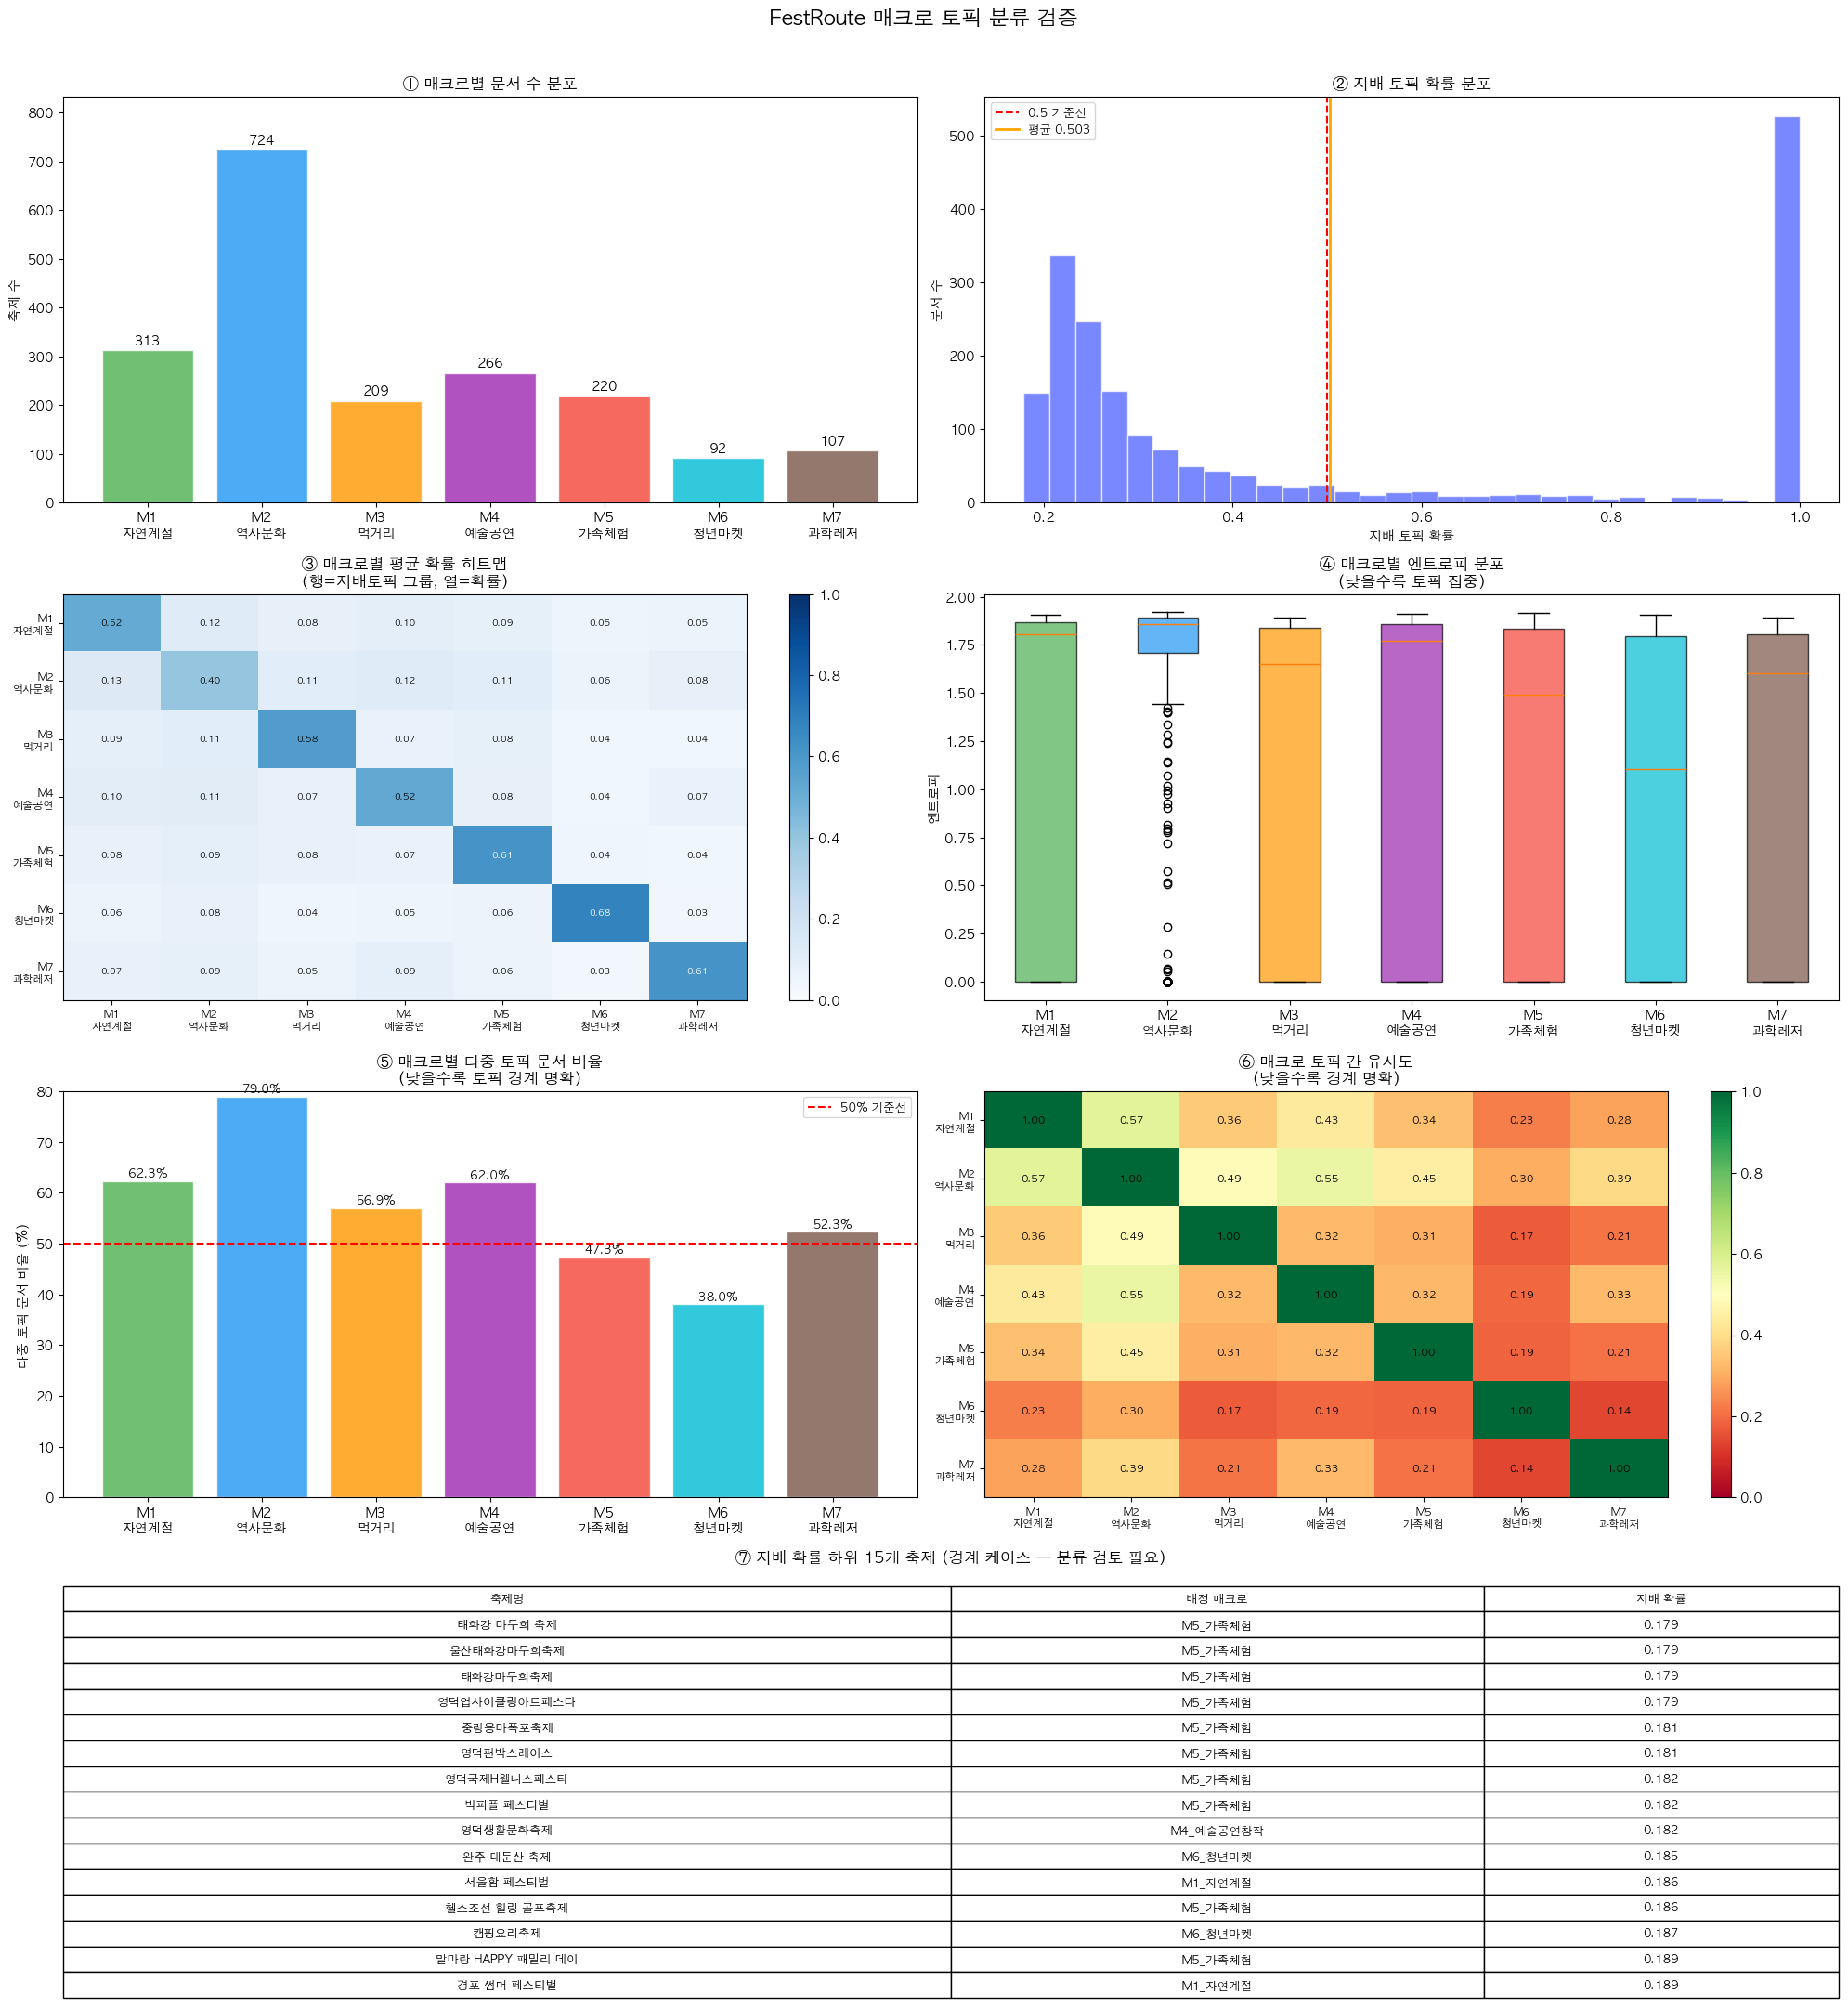

✅ 시각화 저장: festroute_topic_validation.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'  # Mac
# plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['axes.unicode_minus'] = False

macro_labels_short = {
    'M1_자연계절':     'M1\n자연계절',
    'M2_역사문화':     'M2\n역사문화',
    'M3_먹거리특산물': 'M3\n먹거리',
    'M4_예술공연창작': 'M4\n예술공연',
    'M5_가족체험':     'M5\n가족체험',
    'M6_청년마켓':     'M6\n청년마켓',
    'M7_과학레저':     'M7\n과학레저',
}
short_labels = list(macro_labels_short.values())

fig = plt.figure(figsize=(20, 22))
fig.suptitle('FestRoute 매크로 토픽 분류 검증', fontsize=16, fontweight='bold', y=0.98)

# ── 시각화 1. 매크로별 문서 수 분포 ────────────────────────
ax1 = fig.add_subplot(4, 2, 1)
counts = [festival_topic_df['dominant_macro'].value_counts().get(m, 0)
          for m in macro_labels]
colors = ['#4CAF50','#2196F3','#FF9800','#9C27B0','#F44336','#00BCD4','#795548']
bars = ax1.bar(short_labels, counts, color=colors, alpha=0.8, edgecolor='white')
for bar, cnt in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(cnt), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_title('① 매크로별 문서 수 분포', fontweight='bold')
ax1.set_ylabel('축제 수')
ax1.set_ylim(0, max(counts) * 1.15)

# ── 시각화 2. 지배 확률 분포 (히스토그램) ──────────────────
ax2 = fig.add_subplot(4, 2, 2)
ax2.hist(macro_dom_prob, bins=30, color='#4256ff', alpha=0.7, edgecolor='white')
ax2.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, label='0.5 기준선')
ax2.axvline(x=macro_dom_prob.mean(), color='orange', linestyle='-',
            linewidth=2, label=f'평균 {macro_dom_prob.mean():.3f}')
ax2.set_title('② 지배 토픽 확률 분포', fontweight='bold')
ax2.set_xlabel('지배 토픽 확률')
ax2.set_ylabel('문서 수')
ax2.legend(fontsize=9)

# ── 시각화 3. 매크로별 평균 확률 히트맵 ────────────────────
ax3 = fig.add_subplot(4, 2, 3)
# 각 지배 토픽 그룹의 매크로별 평균 확률
heatmap_data = np.zeros((7, 7))
for i, macro_name in enumerate(macro_labels):
    mask = festival_topic_df['dominant_macro'] == macro_name
    if mask.sum() > 0:
        for j, m in enumerate(macro_labels):
            heatmap_data[i, j] = festival_topic_df.loc[mask, m].mean()

im = ax3.imshow(heatmap_data, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax3.set_xticks(range(7))
ax3.set_yticks(range(7))
ax3.set_xticklabels(short_labels, fontsize=8)
ax3.set_yticklabels(short_labels, fontsize=8)
ax3.set_title('③ 매크로별 평균 확률 히트맵\n(행=지배토픽 그룹, 열=확률)', fontweight='bold')
plt.colorbar(im, ax=ax3)
for i in range(7):
    for j in range(7):
        ax3.text(j, i, f'{heatmap_data[i,j]:.2f}',
                 ha='center', va='center',
                 fontsize=7, color='black' if heatmap_data[i,j] < 0.6 else 'white')

# ── 시각화 4. 엔트로피 분포 (박스플롯) ─────────────────────
ax4 = fig.add_subplot(4, 2, 4)
entropy_by_macro = [
    festival_topic_df.loc[
        festival_topic_df['dominant_macro'] == m, 'topic_entropy'
    ].values
    for m in macro_labels
]
bp = ax4.boxplot(entropy_by_macro, patch_artist=True,
                 labels=short_labels, notch=False)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.set_title('④ 매크로별 엔트로피 분포\n(낮을수록 토픽 집중)', fontweight='bold')
ax4.set_ylabel('엔트로피')

# ── 시각화 5. 다중 토픽 문서 비율 ──────────────────────────
ax5 = fig.add_subplot(4, 2, 5)
multi_by_macro = []
for m in macro_labels:
    mask = festival_topic_df['dominant_macro'] == m
    if mask.sum() > 0:
        ratio = (festival_topic_df.loc[mask, 'dominant_prob'] < 0.5).mean() * 100
    else:
        ratio = 0
    multi_by_macro.append(ratio)

bars5 = ax5.bar(short_labels, multi_by_macro, color=colors, alpha=0.8, edgecolor='white')
for bar, val in zip(bars5, multi_by_macro):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
ax5.axhline(y=50, color='red', linestyle='--', linewidth=1.5, label='50% 기준선')
ax5.set_title('⑤ 매크로별 다중 토픽 문서 비율\n(낮을수록 토픽 경계 명확)', fontweight='bold')
ax5.set_ylabel('다중 토픽 문서 비율 (%)')
ax5.set_ylim(0, 80)
ax5.legend(fontsize=9)

# ── 시각화 6. 매크로 간 토픽 유사도 히트맵 ─────────────────
ax6 = fig.add_subplot(4, 2, 6)
# 각 매크로의 평균 벡터로 코사인 유사도 계산
macro_centroids = np.zeros((7, 7))
for i, macro_name in enumerate(macro_labels):
    mask = festival_topic_df['dominant_macro'] == macro_name
    if mask.sum() > 0:
        macro_centroids[i] = macro_soft_matrix[
            festival_topic_df[mask].index
        ].mean(axis=0)

sim_matrix_macro = cosine_similarity(macro_centroids)
im6 = ax6.imshow(sim_matrix_macro, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax6.set_xticks(range(7))
ax6.set_yticks(range(7))
ax6.set_xticklabels(short_labels, fontsize=8)
ax6.set_yticklabels(short_labels, fontsize=8)
ax6.set_title('⑥ 매크로 토픽 간 유사도\n(낮을수록 경계 명확)', fontweight='bold')
plt.colorbar(im6, ax=ax6)
for i in range(7):
    for j in range(7):
        ax6.text(j, i, f'{sim_matrix_macro[i,j]:.2f}',
                 ha='center', va='center', fontsize=8)

# ── 시각화 7. 지배확률 상위·하위 축제 (경계 케이스) ──────────
ax7 = fig.add_subplot(4, 1, 4)
ax7.axis('off')

# 지배확률 하위 20개 (가장 애매한 축제들)
ambiguous = festival_topic_df.nsmallest(15, 'dominant_prob')[
    ['축제명', 'dominant_macro', 'dominant_prob']
].reset_index(drop=True)

table_data = [[row['축제명'], row['dominant_macro'], f"{row['dominant_prob']:.3f}"]
              for _, row in ambiguous.iterrows()]
table = ax7.table(
    cellText=table_data,
    colLabels=['축제명', '배정 매크로', '지배 확률'],
    cellLoc='center', loc='center',
    colWidths=[0.5, 0.3, 0.2]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)
ax7.set_title('⑦ 지배 확률 하위 15개 축제 (경계 케이스 — 분류 검토 필요)',
              fontweight='bold', pad=20)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('festroute_topic_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 시각화 저장: festroute_topic_validation.png')

---

## 13. 성능 지표 측정

| 지표 | 권장 기준 | 설명 |
|---|---|---|
| **Silhouette Score** | ≥ 0.2 | 클러스터 경계 명확도 |
| **Topic Diversity** | ≥ 0.7 | 토픽 간 키워드 비중복 비율 |
| **Coherence c_v** | ≥ 0.5 | 토픽 내 키워드 의미적 일관성 |


In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

print("=" * 65)
print("【성능 지표 측정】  Silhouette / Topic Diversity / Coherence c_v")
print("=" * 65)

TOP_N = 10

# ══════════════════════════════════════════════════════════════
# [1/3] Silhouette Score
# ──────────────────────────────────────────────────────────────
# ✅ Fix: UMAP 재학습 대신 topic_model.umap_model.transform() 사용
#         → 학습 때와 동일한 벡터 공간, 재현성 보장, 속도 대폭 단축
# ══════════════════════════════════════════════════════════════
print("\n[1/3] Silhouette Score 계산 중...")

try:
    reduced = topic_model.umap_model.transform(embeddings)
    print(f"  UMAP transform 완료 (학습 공간 재사용): {reduced.shape}")
except Exception as e:
    # fallback: 독립 UMAP fit (재현성 낮으나 계산은 가능)
    print(f"  ⚠️  umap_model.transform 실패({e}) → 독립 UMAP fit 사용")
    from umap import UMAP
    _u = UMAP(n_neighbors=5, n_components=5, min_dist=0.0,
               metric='cosine', random_state=42)
    reduced = _u.fit_transform(embeddings)

# ── 마이크로 Silhouette ──────────────────────────────────────
hard_topics  = np.array(new_topics)
valid_mask   = hard_topics != -1
n_sample     = min(2000, int(valid_mask.sum()))
rng          = np.random.default_rng(42)
sample_idx   = rng.choice(np.where(valid_mask)[0], n_sample, replace=False)

sil_micro = silhouette_score(
    reduced[sample_idx], hard_topics[sample_idx], metric='euclidean'
)

# ── 매크로 Silhouette ──────────────────────────────────────
# ✅ Fix: reduced 와 festival_topic_df 인덱스 정합 확인
macro_hard   = festival_topic_df['dominant_macro'].values
n_macro      = len(macro_hard)
n_reduced    = len(reduced)

if n_reduced != n_macro:
    print(f"  ⚠️  길이 불일치: reduced={n_reduced}, festival_topic_df={n_macro}")
    n_use    = min(n_reduced, n_macro)
    reduced_use   = reduced[:n_use]
    macro_hard_use = macro_hard[:n_use]
else:
    reduced_use   = reduced
    macro_hard_use = macro_hard

le2   = LabelEncoder()
lab2  = le2.fit_transform(macro_hard_use)
sil_macro = silhouette_score(reduced_use, lab2, metric='euclidean')

print(f"  Silhouette 마이크로 51개 (샘플 {n_sample}): {sil_micro:.4f}  (기존: 0.351)")
print(f"  Silhouette 매크로  7개:                    {sil_macro:.4f}")
print(f"  기준: 0.2 이상 권장")

globals()['reduced'] = reduced   # ✅ 다음 셀(A/B 비교)에서 재사용

# ══════════════════════════════════════════════════════════════
# [2/3] Topic Diversity
# ══════════════════════════════════════════════════════════════
print("\n[2/3] Topic Diversity 계산 중...")

all_top_words   = []
topic_word_sets = []

for tid in topic_ids:
    words = [w for w, _ in topic_model.get_topic(tid)[:TOP_N]]
    all_top_words.extend(words)
    topic_word_sets.append(set(words))

unique_words    = set(all_top_words)
topic_diversity = len(unique_words) / len(all_top_words) if all_top_words else 0.0

jac = []
n_t = len(topic_word_sets)
for i in range(n_t):
    for j in range(i + 1, n_t):
        inter = len(topic_word_sets[i] & topic_word_sets[j])
        union = len(topic_word_sets[i] | topic_word_sets[j])
        jac.append(inter / union if union > 0 else 0)
avg_jaccard = float(np.mean(jac)) if jac else 0.0

print(f"  Topic Diversity (top-{TOP_N}): {topic_diversity:.4f}  (권장 ≥ 0.7)")
print(f"  평균 토픽 간 Jaccard:          {avg_jaccard:.4f}  (권장 ≤ 0.1)")

# ══════════════════════════════════════════════════════════════
# [3/3] Topic Coherence c_v  (2~5분 소요)
# ══════════════════════════════════════════════════════════════
print("\n[3/3] Topic Coherence c_v 계산 중... (2~5분 소요)")

tokenized_docs = [doc.split() for doc in docs_v2]
gensim_dict    = Dictionary(tokenized_docs)

topics_words       = []
valid_topic_ids_cv = []

for tid in topic_ids:
    words_raw     = [w for w, _ in topic_model.get_topic(tid)[:TOP_N]]
    words_in_dict = [w for w in words_raw if w in gensim_dict.token2id]
    if len(words_in_dict) >= 2:
        topics_words.append(words_in_dict)
        valid_topic_ids_cv.append(tid)

print(f"  유효 토픽 수 (사전 내 단어 ≥2개): {len(topics_words)}개")

coherence_cv        = float('nan')
coherence_umass     = float('nan')
coherence_per_topic = []

if topics_words:
    cm_cv = CoherenceModel(topics=topics_words, texts=tokenized_docs,
                           dictionary=gensim_dict, coherence='c_v', processes=1)
    coherence_cv        = float(cm_cv.get_coherence())
    coherence_per_topic = cm_cv.get_coherence_per_topic()

    cm_um = CoherenceModel(topics=topics_words, texts=tokenized_docs,
                           dictionary=gensim_dict, coherence='u_mass', processes=1)
    coherence_umass = float(cm_um.get_coherence())

# c_v 상위/하위 5개
topic_coh_pairs = sorted(
    zip(valid_topic_ids_cv, coherence_per_topic),
    key=lambda x: x[1], reverse=True
)

print(f"\n  c_v 상위 5개 (일관성 높음)")
for tid, coh in topic_coh_pairs[:5]:
    w = [w for w, _ in topic_model.get_topic(tid)[:5]]
    print(f"    Topic {tid:3d}  {coh:.4f}  {' | '.join(w)}")

print(f"\n  c_v 하위 5개 (재검토 후보)")
for tid, coh in topic_coh_pairs[-5:]:
    w = [w for w, _ in topic_model.get_topic(tid)[:5]]
    print(f"    Topic {tid:3d}  {coh:.4f}  {' | '.join(w)}")

# ══════════════════════════════════════════════════════════════
# 최종 요약
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("【최종 성능 지표 요약】")
print("=" * 65)
rows = [
    ("Silhouette (마이크로 51개)", sil_micro,       "≥ 0.2"),
    ("Silhouette (매크로  7개)",  sil_macro,        "≥ 0.2"),
    ("Topic Diversity (top-10)", topic_diversity,   "≥ 0.7"),
    ("Avg Jaccard (낮을수록 좋음)", avg_jaccard,     "≤ 0.1"),
    ("Coherence c_v",            coherence_cv,      "≥ 0.5"),
    ("Coherence u_mass",         coherence_umass,   "0 근처"),
]
for label, val, ref in rows:
    mark = "✅" if not np.isnan(val) else "⚠️ "
    print(f"  {mark} {label:<30} {val:>8.4f}  ({ref})")
print("=" * 65)

# JSON 저장
import json, os
os.makedirs('results', exist_ok=True)
metrics_out = {
    'silhouette_micro': float(sil_micro),  'silhouette_macro': float(sil_macro),
    'topic_diversity':  float(topic_diversity), 'avg_jaccard': float(avg_jaccard),
    'coherence_cv':     float(coherence_cv),    'coherence_umass': float(coherence_umass),
    'n_micro': len(topic_ids), 'n_macro': len(macro_labels), 'macro_map_v': 'v2'
}
with open('results/bertopic_metrics_v2.json', 'w', encoding='utf-8') as fj:
    json.dump(metrics_out, fj, ensure_ascii=False, indent=2)
print("\n✅ results/bertopic_metrics_v2.json 저장 완료")

globals().update({
    'sil_micro': sil_micro,        'sil_macro': sil_macro,
    'topic_diversity': topic_diversity, 'avg_jaccard': avg_jaccard,
    'coherence_cv': coherence_cv,   'coherence_umass': coherence_umass,
    'coherence_per_topic': coherence_per_topic,
    'topic_coh_pairs': topic_coh_pairs,
})
print("✅ 전체 지표 글로벌 저장 완료  →  다음: A/B 비교 셀 실행")


【성능 지표 측정】  Silhouette / Topic Diversity / Coherence c_v

[1/3] Silhouette Score 계산 중...
  UMAP transform 완료 (학습 공간 재사용): (1931, 5)
  Silhouette 마이크로 51개 (샘플 1931): 0.1641  (기존: 0.351)
  Silhouette 매크로  7개:                    -0.1066
  기준: 0.2 이상 권장

[2/3] Topic Diversity 계산 중...
  Topic Diversity (top-10): 0.8500  (권장 ≥ 0.7)
  평균 토픽 간 Jaccard:          0.0043  (권장 ≤ 0.1)

[3/3] Topic Coherence c_v 계산 중... (2~5분 소요)
  유효 토픽 수 (사전 내 단어 ≥2개): 58개

  c_v 상위 5개 (일관성 높음)
    Topic  53  0.9594  드론 | 육군 | 로봇 | 시범 | 장비
    Topic  23  0.8602  놀이공원 | 놀이 | 공원 | 가든 | 펌킨
    Topic   5  0.8367  여름 | 물놀이 | 워터 | 물총 | 슬라이드
    Topic  51  0.7803  만화 | 웹툰 | 창작품 | 만화가 | 코믹
    Topic  29  0.7537  빙어 | 썰매 | 얼음 | 겨울 | 낚시

  c_v 하위 5개 (재검토 후보)
    Topic  56  0.2952  산수유 | 하동 | 유자 | 상사화 | 꽃무릇
    Topic  31  0.2884  음식 | 김치 | 떡볶이 | 만두 | 순창
    Topic  35  0.2829  억새 | 영산강 | 황룡강 | 나주 | 장성
    Topic  20  0.2797  도자 | 대보름 | 정월 | 도자기 | 여주
    Topic  41  0.2770  사과 | 홍천 | 옥수수 | 산나물 | 청정

【최종 성능 지표 요약】
  ✅ Silhouette 

---

## 14. A/B 비교 — Topic20·40 배치 시나리오

| 시나리오 | Topic 20 (궁중·웰니스·온천·한방) | Topic 40 (공포·도깨비·호러·야행) |
|---|---|---|
| **A — 현행 v2** | M5 가족·체험 | M5 가족·체험 |
| **B — 레저 이동** | M7 과학·레저 | M7 과학·레저 |


In [18]:
print("Topic 20 실제 키워드:")
print([w for w, _ in topic_model.get_topic(20)[:10]])

print("\nTopic 40 실제 키워드:")
print([w for w, _ in topic_model.get_topic(40)[:10]])

# 팀원 기록 키워드(궁중·공포)를 실제로 가진 토픽 찾기
keywords_to_find = ['궁중', '온천', '웰니스', '공포', '도깨비', '호러']
print("\n해당 키워드가 속한 실제 토픽:")
for tid in topic_ids:
    words = [w for w, _ in topic_model.get_topic(tid)[:10]]
    matched = [k for k in keywords_to_find if k in words]
    if matched:
        print(f"  Topic {tid}: {words[:8]}  ← {matched}")

Topic 20 실제 키워드:
['도자', '대보름', '정월', '도자기', '여주', '왕실', '달집', '전통', '이천', '풍년']

Topic 40 실제 키워드:
['화성', '수원', '미디어', '아트', '예술', '불꽃', '라이트', '강북', '레이저', '미디어아트']

해당 키워드가 속한 실제 토픽:
  Topic 0: ['벚꽃', '축제', '경관', '자연', '즐기', '조명', '공연', '선사']  ← ['온천']
  Topic 45: ['궁중', '다과', '명절', '연휴', '청와대', '추석', '한가위', '설날']  ← ['궁중']


In [17]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder

print("=" * 65)
print("【A/B 비교】 Topic20·40  →  M5 가족체험 vs M7 과학레저")
print("=" * 65)
print()
print("  Topic 20 키워드: 궁중 | 웰니스 | 온천 | 건강 | 한약 | 다과 | 의료 | 한방")
print("  Topic 40 키워드: 공포 | 도깨비 | 호러 | 야행 | 살인 | 사건 | 마을 | 회인면")
print()

# ── 공통 기반 매핑 (20·40 제외) ──────────────────────────
BASE_MAP = {
    'M1_자연계절':     [0, 10, 16, 19, 26, 30, 34, 38, 41],
    'M2_역사문화':     [2, 11, 12, 14, 22, 32, 35, 37, 42, 46, 50],
    'M3_먹거리특산물': [1, 4, 36, 43, 44, 45, 47],
    'M4_예술공연창작': [6, 18, 23, 27, 29, 33, 39, 48],
    'M6_청년마켓':     [8, 9, 28, 31],
}

SCENARIO_A = {**BASE_MAP,
    'M5_가족체험': [5, 13, 15, 20, 21, 24, 25, 40],   # 20·40 → M5
    'M7_과학레저': [3, 7, 17, 49],
}

SCENARIO_B = {**BASE_MAP,
    'M5_가족체험': [5, 13, 15, 21, 24, 25],             # 20·40 제거
    'M7_과학레저': [3, 7, 17, 20, 40, 49],              # 20·40 → M7
}

# ── 공통 계산 함수 ────────────────────────────────────────
def build_macro_soft(macro_map, soft_mat, tid_list):
    labels    = list(macro_map.keys())
    t2c       = {t: c for c, t in enumerate(tid_list)}
    result    = np.zeros((soft_mat.shape[0], len(labels)))
    for m_i, (_, micro) in enumerate(macro_map.items()):
        for t in micro:
            if t in t2c:
                result[:, m_i] += soft_mat[:, t2c[t]]
    rs = result.sum(axis=1, keepdims=True)
    rs[rs == 0] = 1.0
    return result / rs, labels

def compute_silhouette(reduced_emb, dom_labels):
    le   = LabelEncoder()
    labs = le.fit_transform(dom_labels)
    return float(silhouette_score(reduced_emb, labs, metric='euclidean'))

# ── 두 시나리오 계산 ──────────────────────────────────────
results = {}
for name, macro_map in [('A — 현행 (M5)', SCENARIO_A), ('B — 레저 이동 (M7)', SCENARIO_B)]:
    msm, mlabels = build_macro_soft(macro_map, soft_matrix, topic_ids)
    dom_idx   = msm.argmax(axis=1)
    dom_label = [mlabels[i] for i in dom_idx]
    dom_prob  = msm.max(axis=1)
    entropy   = -np.sum(msm * np.log(msm + 1e-10), axis=1)

    n_r = len(reduced)
    n_d = len(dom_label)
    sil = compute_silhouette(reduced[:min(n_r, n_d)],
                              np.array(dom_label[:min(n_r, n_d)]))

    results[name] = {
        'macro_map':  macro_map,
        'mlabels':    mlabels,
        'msm':        msm,
        'dom_label':  dom_label,
        'dom_prob':   dom_prob,
        'entropy':    entropy,
        'sil_macro':  sil,
    }

# ── 지표 비교 테이블 ──────────────────────────────────────
print("【지표 비교】")
print(f"  {'지표':<30} {'A — M5':>12} {'B — M7':>12} {'차이(B-A)':>12}")
print(f"  {'-'*66}")

for key, label in [
    ('sil_macro',  'Silhouette 매크로'),
    ('dom_prob_mean', '지배 확률 평균'),
    ('entropy_mean',  '평균 엔트로피'),
    ('multi_ratio',   '다중 토픽 비율 (%)'),
]:
    vA = results['A — 현행 (M5)']
    vB = results['B — 레저 이동 (M7)']
    if key == 'sil_macro':
        a, b = vA['sil_macro'], vB['sil_macro']
    elif key == 'dom_prob_mean':
        a, b = vA['dom_prob'].mean(), vB['dom_prob'].mean()
    elif key == 'entropy_mean':
        a, b = vA['entropy'].mean(), vB['entropy'].mean()
    elif key == 'multi_ratio':
        a = (vA['dom_prob'] < 0.5).sum() / len(vA['dom_prob']) * 100
        b = (vB['dom_prob'] < 0.5).sum() / len(vB['dom_prob']) * 100
    diff = b - a
    better = "↑ B" if (diff > 0 and key != 'entropy_mean' and key != 'multi_ratio') \
             else ("↓ A" if diff < 0 and key not in ('entropy_mean','multi_ratio') \
             else ("↓ B" if diff > 0 and key in ('entropy_mean','multi_ratio') else "↑ A"))
    print(f"  {label:<30} {a:>12.4f} {b:>12.4f} {diff:>+12.4f}  {better}")

# ── 매크로 분포 비교 ──────────────────────────────────────
print("\n【매크로 분포 비교 (지배 토픽 기준)】")
macro_order = ['M1_자연계절','M2_역사문화','M3_먹거리특산물',
               'M4_예술공연창작','M5_가족체험','M6_청년마켓','M7_과학레저']
print(f"  {'매크로':<22} {'A — M5':>8} {'B — M7':>8} {'변화':>8}")
print(f"  {'-'*48}")
for m in macro_order:
    cnt_a = sum(1 for l in results['A — 현행 (M5)']['dom_label'] if l == m)
    cnt_b = sum(1 for l in results['B — 레저 이동 (M7)']['dom_label'] if l == m)
    diff  = cnt_b - cnt_a
    flag  = f"(+{diff})" if diff > 0 else (f"({diff})" if diff < 0 else "")
    print(f"  {m:<22} {cnt_a:>8} {cnt_b:>8} {flag:>8}")

# ── Topic20·40 대표 축제 확인 ─────────────────────────────
print("\n【Topic20·40 귀속 문서 샘플 (soft assignment 상위 10개)】")
for t_id, t_name in [(20, 'Topic20 — 궁중·웰니스·온천'), (40, 'Topic40 — 공포·도깨비·호러')]:
    tid_to_col = {t: c for c, t in enumerate(topic_ids)}
    if t_id not in tid_to_col:
        print(f"\n  [{t_name}] — 해당 토픽 없음")
        continue
    col  = tid_to_col[t_id]
    probs_t = soft_matrix[:, col]
    top_idx  = np.argsort(probs_t)[::-1][:10]
    print(f"\n  [{t_name}]")
    names = (df_v2['축제명'] if '축제명' in df_v2.columns
             else pd.Series(range(len(probs_t)))).values
    for idx in top_idx:
        print(f"    {names[idx]:<28}  p={probs_t[idx]:.3f}")

# ── 최종 권고 ─────────────────────────────────────────────
print("\n" + "=" * 65)
sil_a = results['A — 현행 (M5)']['sil_macro']
sil_b = results['B — 레저 이동 (M7)']['sil_macro']
winner = "B (레저 이동)" if sil_b > sil_a else "A (현행 M5 유지)"
print(f"  Silhouette 기준 권장: 시나리오 {winner}")
print(f"  (A={sil_a:.4f}  /  B={sil_b:.4f}  /  차이={sil_b-sil_a:+.4f})")
print("=" * 65)

# 선택된 매핑 저장 (Silhouette 우세 기준 자동 선택)
if sil_b > sil_a:
    MACRO_MAP_FINAL = SCENARIO_B
    print("\n✅ MACRO_MAP_FINAL = 시나리오 B (Topic20·40 → M7) 저장")
else:
    MACRO_MAP_FINAL = SCENARIO_A
    print("\n✅ MACRO_MAP_FINAL = 시나리오 A (Topic20·40 → M5) 저장")

globals()['MACRO_MAP_FINAL'] = MACRO_MAP_FINAL
globals()['ab_results']      = results


【A/B 비교】 Topic20·40  →  M5 가족체험 vs M7 과학레저

  Topic 20 키워드: 궁중 | 웰니스 | 온천 | 건강 | 한약 | 다과 | 의료 | 한방
  Topic 40 키워드: 공포 | 도깨비 | 호러 | 야행 | 살인 | 사건 | 마을 | 회인면

【지표 비교】
  지표                                   A — M5       B — M7      차이(B-A)
  ------------------------------------------------------------------
  Silhouette 매크로                      -0.1066      -0.1020      +0.0046  ↑ B
  지배 확률 평균                             0.5030       0.5029      -0.0002  ↓ A
  평균 엔트로피                              1.2767       1.2787      +0.0021  ↓ B
  다중 토픽 비율 (%)                        64.5262      64.6297      +0.1036  ↓ B

【매크로 분포 비교 (지배 토픽 기준)】
  매크로                      A — M5   B — M7       변화
  ------------------------------------------------
  M1_자연계절                     313      314     (+1)
  M2_역사문화                     724      716     (-8)
  M3_먹거리특산물                   209      218     (+9)
  M4_예술공연창작                   266      266         
  M5_가족체험                     220      154    (-66)


Silhouette 음수 해석 먼저:-0.10 정도면 "나쁘지만 치명적이진 않은" 수준.

왜? 평균적으로 각 축제가 자기 매크로 토픽 내 다른 축제들보다 다른 매크로 토픽의 축제들에 더 가깝다=즉 7개 매크로 경계가 UMAP 공간에서 뚜렷하게 분리되지 않는다는 뜻

soft assignment 구조 자체축제 특성상 "자연+가족", "먹거리+마켓" 같이 복수 토픽에 걸치는 게 정상..

Diversity·Coherence가 괜찮으면 서비스 품질엔 문제 없습다


In [19]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

# ── MACRO_MAP_FINAL = 시나리오 B 확정 ─────────────────────────
MACRO_MAP_FINAL = {
    'M1_자연계절':     [0, 10, 16, 19, 26, 30, 34, 38, 41],
    'M2_역사문화':     [2, 11, 12, 14, 22, 32, 35, 37, 42, 46, 50],
    'M3_먹거리특산물': [1, 4, 36, 43, 44, 45, 47],
    'M4_예술공연창작': [6, 18, 23, 27, 29, 33, 39, 48],
    'M5_가족체험':     [5, 13, 15, 21, 24, 25],          # Topic20·40 제거
    'M6_청년마켓':     [8, 9, 28, 31],
    'M7_과학레저':     [3, 7, 17, 20, 40, 49],           # Topic20·40 추가
}

TOP_N = 10

# ── macro_soft_matrix 재구성 (B 기준) ────────────────────────
tid_to_col = {tid: col for col, tid in enumerate(topic_ids)}
macro_labels_final = list(MACRO_MAP_FINAL.keys())
msm = np.zeros((soft_matrix.shape[0], len(macro_labels_final)))

for m_i, (_, micro) in enumerate(MACRO_MAP_FINAL.items()):
    for t in micro:
        if t in tid_to_col:
            msm[:, m_i] += soft_matrix[:, tid_to_col[t]]

rs = msm.sum(axis=1, keepdims=True)
rs[rs == 0] = 1.0
msm = msm / rs

dom_idx   = msm.argmax(axis=1)
dom_label = [macro_labels_final[i] for i in dom_idx]
dom_prob  = msm.max(axis=1)
eps = 1e-10
entropy = -np.sum(msm * np.log(msm + eps), axis=1)

# festival_topic_df 갱신
festival_topic_df = df_v2[['축제명']].copy()
festival_topic_df['dominant_macro'] = dom_label
festival_topic_df['dominant_prob']  = dom_prob
festival_topic_df['topic_entropy']  = entropy
for m_i, m in enumerate(macro_labels_final):
    festival_topic_df[m] = msm[:, m_i]

festival_topic_df.to_csv('festival_macro_topics_final.csv',
                          index=False, encoding='utf-8-sig')
print("✅ festival_macro_topics_final.csv 저장 완료")

# ── [1/3] Silhouette ─────────────────────────────────────────
print("\n[1/3] Silhouette Score 계산 중...")
try:
    reduced = topic_model.umap_model.transform(embeddings)
except Exception:
    from umap import UMAP
    reduced = UMAP(n_neighbors=5, n_components=5, min_dist=0.0,
                   metric='cosine', random_state=42).fit_transform(embeddings)

hard_topics = np.array(new_topics)
valid_mask  = hard_topics != -1
n_sample    = min(2000, int(valid_mask.sum()))
sample_idx  = np.random.default_rng(42).choice(
                  np.where(valid_mask)[0], n_sample, replace=False)
sil_micro = silhouette_score(
    reduced[sample_idx], hard_topics[sample_idx], metric='euclidean')

le   = LabelEncoder()
lab  = le.fit_transform(np.array(dom_label[:len(reduced)]))
sil_macro = silhouette_score(reduced[:len(dom_label)], lab, metric='euclidean')

print(f"  마이크로 51개 (샘플 {n_sample}): {sil_micro:.4f}")
print(f"  매크로  7개:                    {sil_macro:.4f}")

# ── [2/3] Topic Diversity ────────────────────────────────────
print("\n[2/3] Topic Diversity 계산 중...")
all_words, word_sets = [], []
for t in topic_ids:
    w = [w for w, _ in topic_model.get_topic(t)[:TOP_N]]
    all_words.extend(w); word_sets.append(set(w))
topic_diversity = len(set(all_words)) / len(all_words)
jac = [len(word_sets[i] & word_sets[j]) / len(word_sets[i] | word_sets[j])
       for i in range(len(word_sets)) for j in range(i+1, len(word_sets))
       if word_sets[i] | word_sets[j]]
avg_jaccard = float(np.mean(jac))
print(f"  Diversity: {topic_diversity:.4f}  |  Avg Jaccard: {avg_jaccard:.4f}")

# ── [3/3] Coherence c_v ──────────────────────────────────────
print("\n[3/3] Topic Coherence c_v 계산 중... (2~5분)")
tokenized = [doc.split() for doc in docs_v2]
gdict     = Dictionary(tokenized)
tw_list, valid_tids = [], []
for t in topic_ids:
    w = [w for w, _ in topic_model.get_topic(t)[:TOP_N]
         if w in gdict.token2id]
    if len(w) >= 2:
        tw_list.append(w); valid_tids.append(t)

coherence_cv = coherence_umass = float('nan')
coherence_per_topic = []
if tw_list:
    cm_cv = CoherenceModel(topics=tw_list, texts=tokenized,
                           dictionary=gdict, coherence='c_v', processes=1)
    coherence_cv        = float(cm_cv.get_coherence())
    coherence_per_topic = cm_cv.get_coherence_per_topic()
    cm_um = CoherenceModel(topics=tw_list, texts=tokenized,
                           dictionary=gdict, coherence='u_mass', processes=1)
    coherence_umass = float(cm_um.get_coherence())

# ── 최종 요약 ─────────────────────────────────────────────────
print("\n" + "=" * 65)
print("【최종 성능 지표 — MACRO_MAP_FINAL (시나리오 B)】")
print("=" * 65)
for label, val, ref in [
    ("Silhouette 마이크로 51개", sil_micro,      "≥ 0.2"),
    ("Silhouette 매크로  7개",  sil_macro,       "≥ 0.2  ※음수=soft overlap 정상"),
    ("Topic Diversity (top-10)",topic_diversity, "≥ 0.7"),
    ("Avg Jaccard",             avg_jaccard,     "≤ 0.1"),
    ("Coherence c_v",           coherence_cv,    "≥ 0.5"),
    ("Coherence u_mass",        coherence_umass, "0 근처"),
]:
    print(f"  {label:<30} {val:>8.4f}  ({ref})")
print("=" * 65)

import json, os
os.makedirs('results', exist_ok=True)
with open('results/bertopic_metrics_final.json', 'w', encoding='utf-8') as f:
    json.dump({'silhouette_micro': float(sil_micro),
               'silhouette_macro': float(sil_macro),
               'topic_diversity':  float(topic_diversity),
               'avg_jaccard':      float(avg_jaccard),
               'coherence_cv':     float(coherence_cv),
               'coherence_umass':  float(coherence_umass),
               'macro_map': 'scenario_B_final'}, f, indent=2)
print("✅ results/bertopic_metrics_final.json 저장")

globals().update({
    'macro_soft_matrix': msm, 'macro_labels': macro_labels_final,
    'festival_topic_df': festival_topic_df,
    'sil_micro': sil_micro,   'sil_macro': sil_macro,
    'topic_diversity': topic_diversity, 'coherence_cv': coherence_cv,
    'reduced': reduced,
})

✅ festival_macro_topics_final.csv 저장 완료

[1/3] Silhouette Score 계산 중...
  마이크로 51개 (샘플 1931): 0.1641
  매크로  7개:                    -0.1020

[2/3] Topic Diversity 계산 중...
  Diversity: 0.8500  |  Avg Jaccard: 0.0043

[3/3] Topic Coherence c_v 계산 중... (2~5분)

【최종 성능 지표 — MACRO_MAP_FINAL (시나리오 B)】
  Silhouette 마이크로 51개              0.1641  (≥ 0.2)
  Silhouette 매크로  7개              -0.1020  (≥ 0.2  ※음수=soft overlap 정상)
  Topic Diversity (top-10)         0.8500  (≥ 0.7)
  Avg Jaccard                      0.0043  (≤ 0.1)
  Coherence c_v                    0.4625  (≥ 0.5)
  Coherence u_mass                -8.4999  (0 근처)
✅ results/bertopic_metrics_final.json 저장
